750 2
250 2
Linear Regression MSE:
11.375126840329845


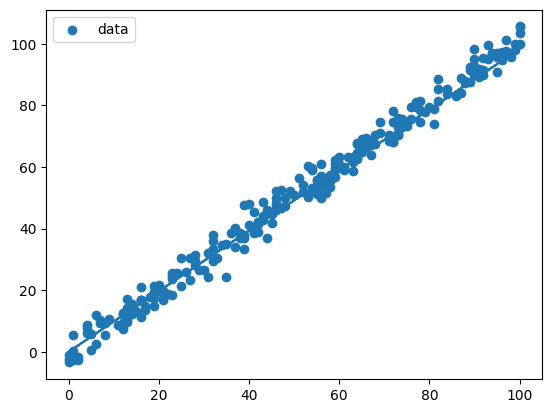

800 2
199 2
Ridge Regression MSE - Average:
7.7559101416110945
Ridge Regression MSE - Best Model:
6.335171883762709
8
Ridge Regression MSE - Best Model Final Test Predictions:
9.393306976055035


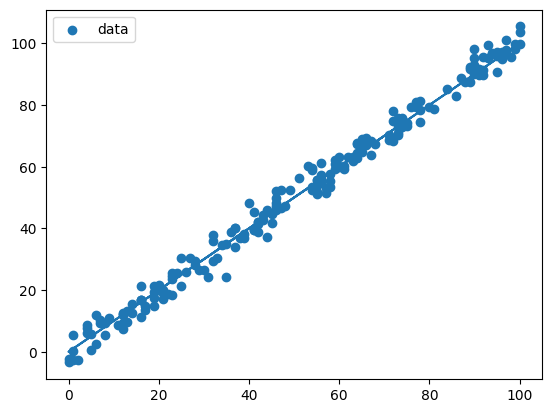

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from typing import Tuple, List

def MSE(y_test, pred):
    '''
        return the mean square error
    '''
    #print('yo')
    return metrics.mean_squared_error(y_test, pred)

def prepare_data(df_train: pd.DataFrame, df_test: pd.DataFrame) -> tuple:
    '''
        Separate input data and labels, remove NaN values. 
        Execute this for both dataframes.
        return tuple of numpy arrays(train_data, train_label, test_data, test_label).
    '''
    df_train_na_dropped = df_train.dropna()
    df_test_na_dropped = df_test.dropna()

    x_train = df_train_na_dropped['x'].to_numpy()
    #print('xtrain',x_train)
    x_train = x_train.reshape(x_train.shape[0], 1)
    #print(x_train)
    y_train = df_train_na_dropped['y'].to_numpy()
    y_train = y_train.reshape(y_train.shape[0], 1)

    x_test  = df_test_na_dropped['x'].to_numpy()
    x_test = x_test.reshape(x_test.shape[0], 1)

    y_test  = df_test_na_dropped['y'].to_numpy()
    y_test = y_test.reshape(y_test.shape[0], 1)

    return x_train, y_train, x_test, y_test

# Download and read the data.
def split_data(filename: str, percent_train: float) -> pd.DataFrame:
    '''
        Given the data filename and percentage of train data, split the data
        into training and test data. 
    '''
    #print('split')
    df = pd.read_csv(filename)
    df_train = df.head(int(df.shape[0] * percent_train))
    df_test = df.tail(int(df.shape[0] * (1-percent_train)))
    print(df_train.shape[0],df_train.shape[1])
    print(df_test.shape[0],df_test.shape[1])
    return df_train, df_test

# Implement LinearRegression class
class LinearRegression:   
    def __init__(self, learning_rate=0.01, epoches=1000):        
        self.learning_rate = learning_rate
        self.iterations    = epoches
        self.W = None
        self.b = None
    
    def fit(self, X, Y):
        #print('fit lin')
        n_samples, n_features = X.shape
        self.W = np.zeros((n_features,1))
        self.b = np.zeros(n_features)
        for _ in range(self.iterations):
            pred = np.dot(X, self.W) + self.b
            db = 1/n_samples * sum(Y - pred)
            dw = 1/n_samples * np.dot(X.T,(Y-pred))
            self.W += self.learning_rate * dw
            self.b += self.learning_rate * db
        pass


    # output      
    def predict(self, X):
        predictions = np.dot(X, self.W) + self.b
        return predictions

class RidgeRegression(): 
    
    def __init__(self, learning_rate=.00001, iterations=1000, penalty=1) : 
        
        self.learning_rate = learning_rate         
        self.iterations = iterations         
        self.penalty = penalty 
        
    # Function for model training             
    def fit(self, X, Y) :       
        # weight initialization  
        n_samples, n_features = X.shape
        self.W = np.zeros((n_features,1))
        self.b = np.zeros(n_features)
        # gradient descent learning   
        for i in range(self.iterations):
        # calculate gradients       
            pred = np.dot(X, self.W) + self.b
            db = 1/n_samples * sum(Y - pred) * -2
            dw = 1/n_samples * (-(2*(np.dot(X.T,(Y-pred))))+(2*(self.penalty * self.W)))
            self.W -= self.learning_rate * dw
            self.b -= self.learning_rate * db
        # update weights     
        pass    

    def predict(self, X):     
        predictions = np.dot(X, self.W) + self.b
        return predictions

def kFold(folds: int, data: pd.DataFrame):
    '''
        Given the training data, iterate through 10 folds and validate 
        10 different Ridge Regression models. 

        Returns:
            mse_avg - Float value of the average MSE between the models. 
            min_model - Integer index of the model with the minimum MSE in models[].
            models - List containing each RidgeRegression() object.
            min_mse - Float value of the minimum MSE. 
    '''   
    models = []
    mse_values = []


    for i in range(folds):
        # Split the data into training and validation sets
        df_train, df_valid = train_test_split(data, train_size=0.9)
        train_X, train_y, valid_X, valid_y = prepare_data(df_train, df_valid)
#rewrite given the functions I
        # Train a Ridge Regression model
        model = RidgeRegression(learning_rate=0.00001, iterations=1000, penalty=1)
        model.fit(train_X, train_y)

        # Validate the model and calculate MSE
        y_pred = model.predict(valid_X)
        mse = MSE(valid_y,y_pred)
        mse_values.append(mse)
        models.append(model)

    # Calculate the average MSE and find the model with the minimum MSE
    mse_avg = np.mean(mse_values)
    min_model = mse_values.index(np.min(mse_values))
    min_mse = np.min(mse_values)

    return mse_avg, min_model, models, min_mse


if __name__ == "__main__":
    
    '''
    PART ONE: Linear Regression
    '''

    #print(1)
    data_path = "./data.csv"
    df_train, df_test = split_data(data_path, .75)
    #print(2)
    train_X, train_y, test_X, test_y = prepare_data(df_train, df_test)
    r = LinearRegression(learning_rate=0.0001, epoches=10)
    r.fit(train_X, train_y)
    #print(3)
    # Make prediction with test set
    preds = r.predict(test_X)
    #print(4)
    # Calculate and print the mean square error of your prediction
    mean_square_error = MSE(test_y, preds[:, :1])
    print("Linear Regression MSE:")
    print(mean_square_error) # I added this
    #print(5)
    #plot your prediction and labels, you can save the plot and add in the report
    plt.scatter(test_X,test_y, label='data')
    plt.plot(test_X, preds)
    plt.legend()
    plt.show()
    #print(6)

    '''
    PART TWO: Ridge Regression and K-Fold Cross Validation
    '''

    df_train, df_test = split_data(data_path, .80)
    kFold_train_X, kFold_train_y, kFold_test_X, kFold_test_y = prepare_data(df_train, df_test)

    mse_avg, min_model, models, mse_min = kFold(10, df_train)
    best_model = models[min_model]

    print("Ridge Regression MSE - Average:")
    print(mse_avg)
    
    print("Ridge Regression MSE - Best Model:")
    print(mse_min)
    print(min_model)
    kFold_preds = best_model.predict(kFold_test_X)
    kFold_mean_square_error = MSE(kFold_test_y, kFold_preds[:, :1])

    print("Ridge Regression MSE - Best Model Final Test Predictions:")
    print(kFold_mean_square_error)

    plt.scatter(kFold_test_X,kFold_test_y, label='data')
    plt.plot(kFold_test_X, kFold_preds)
    plt.legend()
    plt.show()